# K-Means

In [1]:
# ==========================================
# BAGIAN 1 - IMPORT & LOAD DATA
# ==========================================

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load file bersih
df = pd.read_csv("/content/Data_1000_Clean_After_Stopword.csv")

df.head()


,Stemmed_Tokens,Stemmed_Text,Tokens_Final,Tokens_Clean,text_clean
0,"['emiten', 'bumn', 'konstruksi', 'investasi', ...",emiten bumn konstruksi investasi pt pp persero...,"['emiten', 'bumn', 'konstruksi', 'investasi', ...","['emiten', 'ptpp', 'bagi', 'dividen', 'ptpp', ...",emiten ptpp bagi dividen ptpp novel arsyad peg...
1,"['satu', 'tugas', 'satgas', 'bangun', 'infrast...",satu tugas satgas bangun infrastruktur kota ne...,"['satu', 'tugas', 'satgas', 'bangun', 'infrast...","['era', 'bubar', 'hanggodo', 'bubar', 'terbit'...",era bubar hanggodo bubar terbit cabut kepmen m...
2,"['menteri', 'kerja', 'rumah', 'rakyat', 'pupr'...",menteri kerja rumah rakyat pupr resmi bubar sa...,"['menteri', 'kerja', 'rumah', 'rakyat', 'pupr'...","['bubar', 'bubar', 'hanggodo', 'terbit', 'tuan...",bubar bubar hanggodo terbit tuang kepmen cabut...
3,"['menteri', 'kerja', 'pu', 'dody', 'hanggodo',...",menteri kerja pu dody hanggodo bubar satu tuga...,"['menteri', 'kerja', 'dody', 'hanggodo', 'buba...","['hanggodo', 'bubar', 'terbit', 'cabut', 'kepm...",hanggodo bubar terbit cabut kepmen maret timba...
4,"['perintah', 'putus', 'tunda', 'pindah', 'apar...",perintah putus tunda pindah aparatur sipil neg...,"['perintah', 'putus', 'tunda', 'pindah', 'apar...","['tunda', 'picu', 'dinamika', 'sesuai', 'penda...",tunda picu dinamika sesuai pendayagunaan refor...


TF-IDF shape: (1000, 5068)


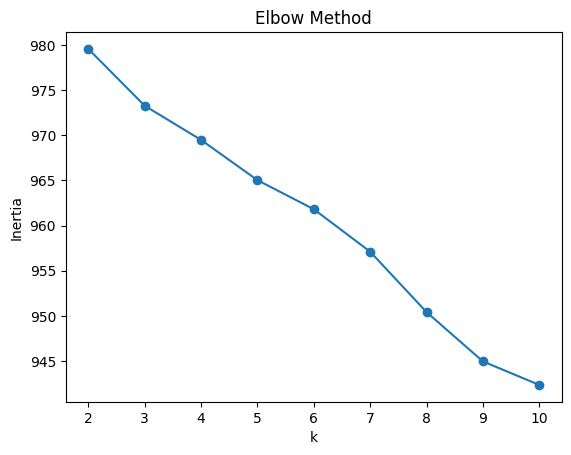

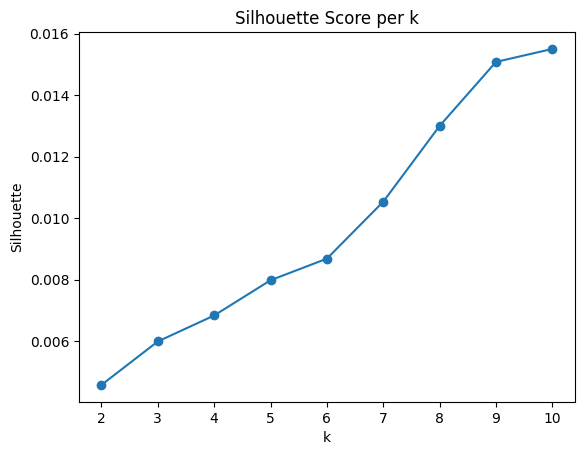

K terbaik: 10


In [2]:
# ==========================================
# BAGIAN 2 - TF-IDF + PENCARIAN K TERBAIK
# ==========================================

# 2. TF-IDF
vectorizer = TfidfVectorizer(min_df=2)
X = vectorizer.fit_transform(df['text_clean'])

print("TF-IDF shape:", X.shape)

# 3. Cari jumlah cluster terbaik
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    preds = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, preds))

# Plot Elbow
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score per k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print("K terbaik:", best_k)


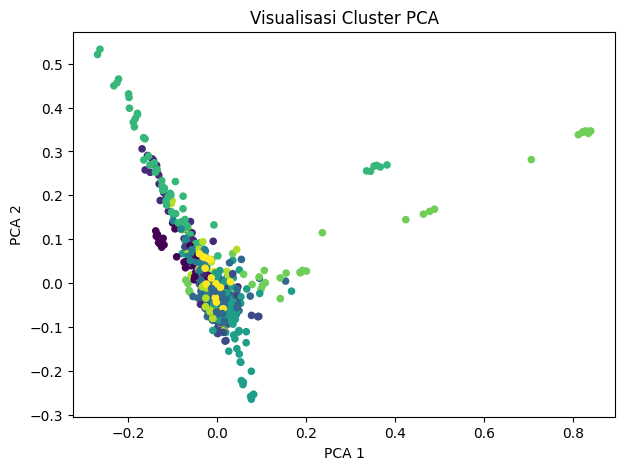

/tmp/ipython-input-1768304316.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Cluster'], palette='viridis')


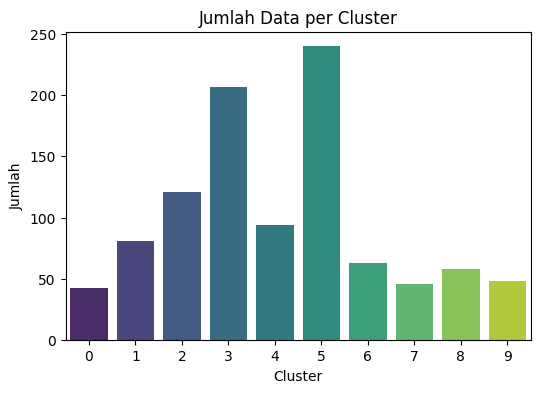

In [3]:
# ==========================================
# BAGIAN 3 - KMEANS FINAL + PCA
# ==========================================

# 4. KMeans final
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X)

# 5. PCA untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(7, 5))
plt.scatter(df['pca1'], df['pca2'], c=df['Cluster'], s=20)
plt.title("Visualisasi Cluster PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 6. Distribusi cluster
plt.figure(figsize=(6,4))
sns.countplot(x=df['Cluster'], palette='viridis')
plt.title("Jumlah Data per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah")
plt.show()


In [4]:
# ==========================================
# BAGIAN 4 - TOP WORDS & SAVE RESULT
# ==========================================

# 7. Top 10 kata per cluster
feature_names = vectorizer.get_feature_names_out()

for cluster_id in range(best_k):
    print(f"\n=== Top 10 Kata Cluster {cluster_id} ===")
    idx = df[df['Cluster'] == cluster_id].index
    mean_tfidf = np.asarray(X[idx].mean(axis=0)).ravel()
    top10_idx = mean_tfidf.argsort()[-10:][::-1]
    for i in top10_idx:
        print(f"{feature_names[i]}: {mean_tfidf[i]:.4f}")

# 8. Simpan hasil lengkap
df.to_csv("clustering_result_clean.csv", index=False)
print("✓ Hasil clustering disimpan ke clustering_result_clean.csv")



=== Top 10 Kata Cluster 0 ===
tenaga: 0.1480
lamar: 0.1233
teknis: 0.1031
bkn: 0.0780
instansi: 0.0779
pns: 0.0707
sehat: 0.0661
lulus: 0.0607
janji: 0.0517
lowong: 0.0491

=== Top 10 Kata Cluster 1 ===
yudikatif: 0.0770
legislatif: 0.0721
selesai: 0.0564
lantik: 0.0398
eksekutif: 0.0389
hasan: 0.0381
era: 0.0346
batch: 0.0345
mpr: 0.0330
bkpm: 0.0324

=== Top 10 Kata Cluster 2 ===
proklamasi: 0.0419
wapres: 0.0385
wita: 0.0380
kena: 0.0331
adat: 0.0315
amin: 0.0304
kursi: 0.0301
teks: 0.0291
tinjau: 0.0265
baju: 0.0265

=== Top 10 Kata Cluster 3 ===
dukung: 0.0405
sig: 0.0229
ramah: 0.0224
ptpp: 0.0209
komitmen: 0.0205
telekomunikasi: 0.0202
internet: 0.0202
bakti: 0.0191
darmawan: 0.0179
semen: 0.0175

=== Top 10 Kata Cluster 4 ===
fungsional: 0.0596
selesai: 0.0464
vvip: 0.0443
siap: 0.0357
segmen: 0.0357
rampung: 0.0328
menit: 0.0313
kesiap: 0.0310
balang: 0.0287
terminal: 0.0258

=== Top 10 Kata Cluster 5 ===
tumbuh: 0.0471
bijak: 0.0249
kuat: 0.0211
dorong: 0.0200
naik: 0.0188
f

# Topic Modeling

LDA


=== TOPIK 0 ===
selesai (201.6652)
dukung (145.8674)
siap (67.0085)
telkom (63.5481)
kena (62.4319)
yudikatif (61.1968)
legislatif (59.9802)
adat (59.4316)
komitmen (52.3411)
sesuai (50.8860)

=== TOPIK 1 ===
tumbuh (307.2187)
bijak (144.7885)
dorong (105.5079)
lamar (98.5175)
besar (91.6079)
dukung (81.1371)
mayapada (72.1959)
manufaktur (71.8352)
lulus (71.4797)
sehat (70.3945)

=== TOPIK 2 ===
banjir (104.1956)
dukung (70.1468)
kuat (64.2665)
family (62.1993)
paskibraka (61.9465)
ptpp (58.0869)
tenggelam (55.1772)
pajak (52.9787)
nasa (51.2020)
sorot (48.1079)

=== TOPIK 3 ===
dukung (234.9749)
huni (217.5788)
tenaga (193.3656)
selesai (181.0309)
sesuai (150.9854)
sehat (111.4102)
fungsi (96.9010)
manfaat (90.6355)
siap (85.9766)
teknis (83.3761)

=== TOPIK 4 ===
gratis (75.6938)
proklamasi (66.1743)
maju (61.2420)
status (59.2266)
gizi (57.3540)
salim (57.0882)
siap (52.9715)
keppres (49.1267)
lantik (48.5101)
sehat (48.2346)


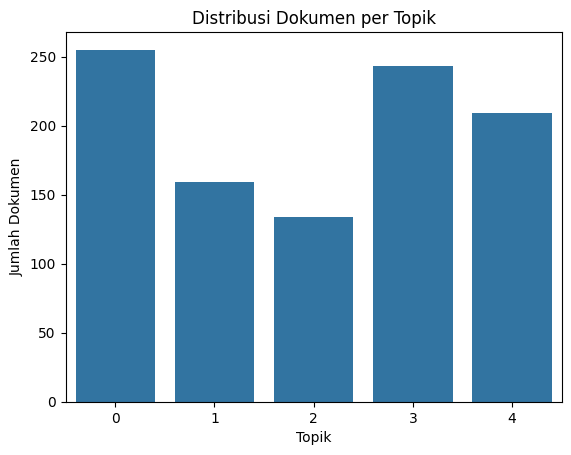

In [17]:
# ==========================================
# TOPIC MODELING LDA
# ==========================================

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Load data bersih
df = pd.read_csv("Data_1000_Clean_After_Stopword.csv")

# 2. Gunakan teks bersih
texts = df['text_clean']

# 3. Vectorizer untuk LDA
vectorizer = CountVectorizer(min_df=3)
X = vectorizer.fit_transform(texts)

# 4. Tentukan jumlah topik
n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch'
)

lda.fit(X)

# 5. Tampilkan 10 kata teratas tiap topik
feature_names = vectorizer.get_feature_names_out()

def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n=== TOPIK {topic_idx} ===")
        top_idx = topic.argsort()[:-n_top_words - 1:-1]
        for idx in top_idx:
            print(f"{feature_names[idx]} ({topic[idx]:.4f})")

print_top_words(lda, feature_names)

# ==========================================
# Distribusi dokumen per topik
# ==========================================

# 6. Tentukan topik dominan untuk setiap dokumen
doc_topic = lda.transform(X)
df['Dominant_Topic'] = doc_topic.argmax(axis=1)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Dominant_Topic'])
plt.title("Distribusi Dokumen per Topik")
plt.xlabel("Topik")
plt.ylabel("Jumlah Dokumen")
plt.show()


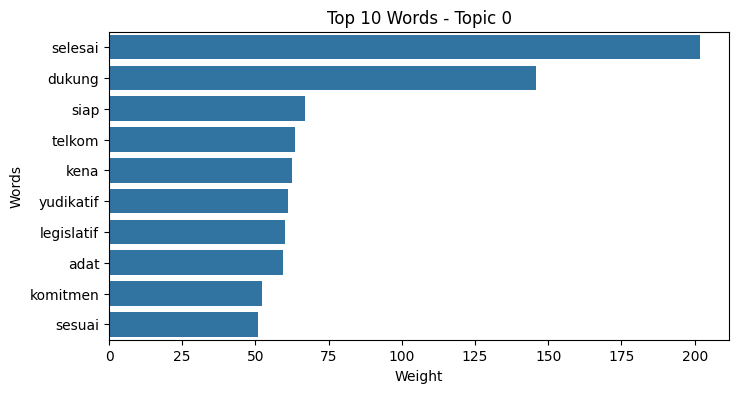

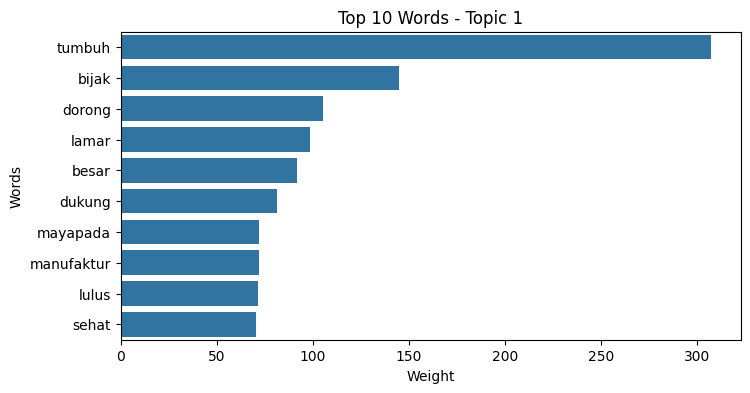

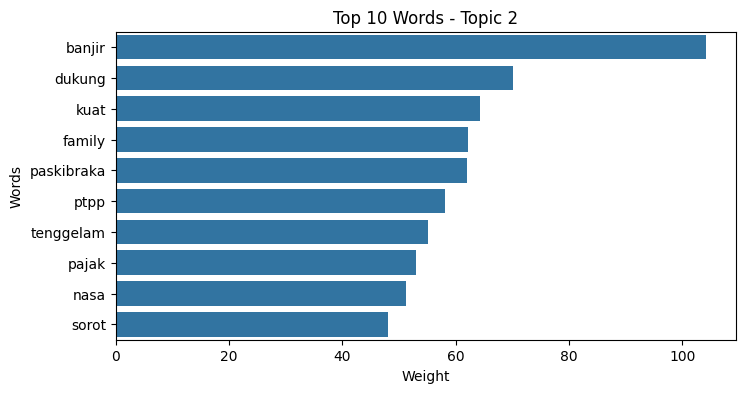

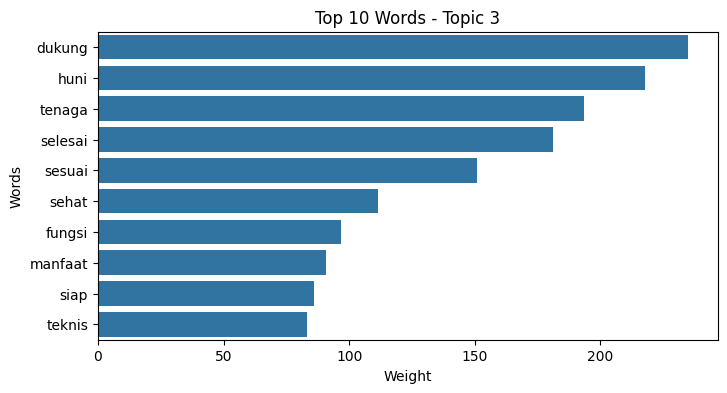

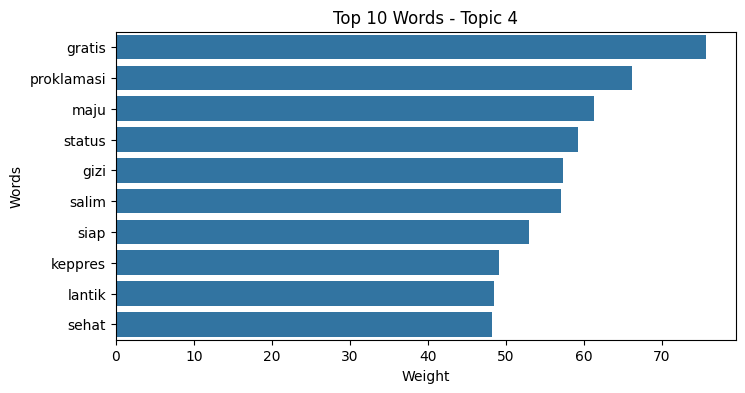

In [18]:
import numpy as np

def plot_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_idx]
        top_values = topic[top_idx]

        plt.figure(figsize=(8,4))
        sns.barplot(x=top_values, y=top_words)
        plt.title(f"Top {n_top_words} Words - Topic {topic_idx}")
        plt.xlabel("Weight")
        plt.ylabel("Words")
        plt.show()

plot_top_words(lda, feature_names)

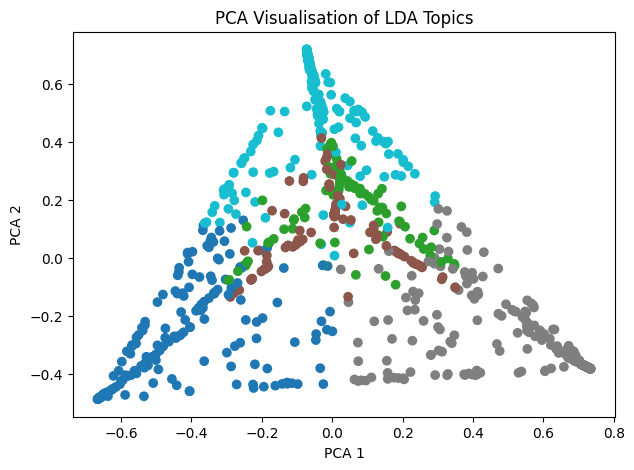

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(doc_topic)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Dominant_Topic'], cmap='tab10')
plt.title("PCA Visualisation of LDA Topics")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

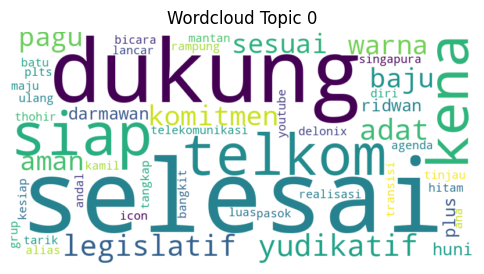

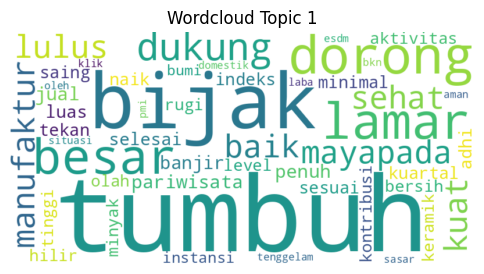

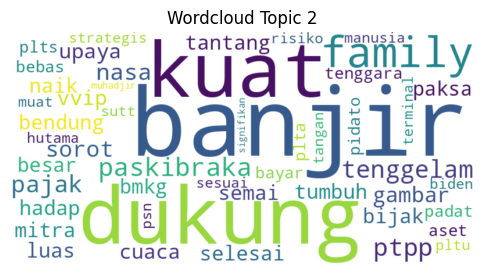

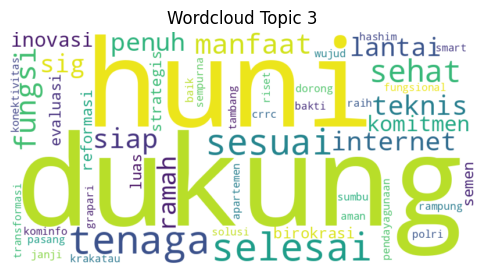

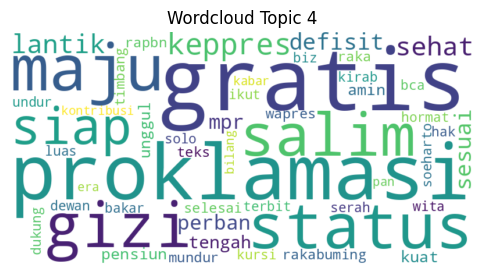

In [21]:
from wordcloud import WordCloud

for topic_idx, topic in enumerate(lda.components_):
    plt.figure(figsize=(6,4))
    top_words = {feature_names[i]: topic[i] for i in topic.argsort()[:-50:-1]}
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Wordcloud Topic {topic_idx}")
    plt.show()

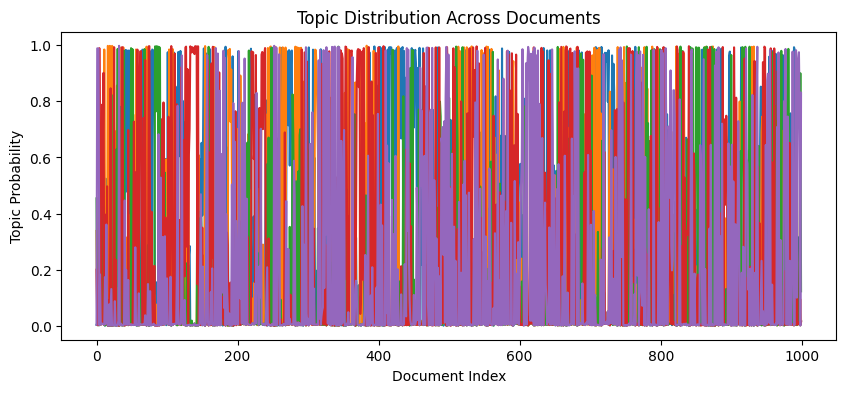

In [22]:
plt.figure(figsize=(10,4))
plt.plot(doc_topic)
plt.title("Topic Distribution Across Documents")
plt.xlabel("Document Index")
plt.ylabel("Topic Probability")
plt.show()

BERTOPIC

In [7]:
!pip install bertopic[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.1 MB/s eta 0:00:00


In [9]:
# ==========================================
# TOPIC MODELING BERTopic + VISUALISASI
# ==========================================

import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# 1. Load data bersih
df = pd.read_csv("Data_1000_Clean_After_Stopword.csv")

# 2. Ambil teks
texts = df['text_clean'].astype(str).tolist()

# 3. Embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# 4. Buat embeddings
embeddings = embedding_model.encode(texts, show_progress_bar=True)

# 5. Buat model
topic_model = BERTopic(verbose=True)

# 6. Fit
topics, probs = topic_model.fit_transform(texts, embeddings)


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2025-12-12 15:56:15,618 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-12 15:56:37,132 - BERTopic - Dimensionality - Completed ✓
2025-12-12 15:56:37,134 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-12 15:56:37,221 - BERTopic - Cluster - Completed ✓
2025-12-12 15:56:37,233 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-12 15:56:37,518 - BERTopic - Representation - Completed ✓


In [10]:
fig = topic_model.visualize_barchart(top_n_topics=10)
fig.show()

In [11]:
fig = topic_model.visualize_term_rank()
fig.show()

In [12]:
fig = topic_model.visualize_topics()
fig.show()

In [13]:
fig = topic_model.visualize_hierarchy()
fig.show()

In [14]:
fig = topic_model.visualize_heatmap()
fig.show()